# Modelo de machine learning

In [ ]:
import pandas as pd
import os

# Crear directorio para guardar figuras
os.makedirs('../figures/03_ml_model', exist_ok=True)

df = pd.read_csv('../data/clean/bank_marketing_clean.csv')

df

,age,balance,duration,campaign,pdays,previous,y,job_unknown,education_unknown,contact_unknown,...,day_of_week_25,day_of_week_26,day_of_week_27,day_of_week_28,day_of_week_29,day_of_week_30,day_of_week_31,poutcome_failure,poutcome_other,poutcome_success
0,58,2143.0,261,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,44,29.0,151,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,33,2.0,76,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,47,1506.0,92,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,33,1.0,198,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,825.0,977,3,-1,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
45207,71,1729.0,456,2,-1,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
45208,72,5715.0,1127,5,184,3,1,0,0,0,...,False,False,False,False,False,False,False,False,False,True
45209,57,668.0,508,4,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


## Hacer split de datos

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop('y', axis=1)
y = df['y']

X.head(5)

,age,balance,duration,campaign,pdays,previous,job_unknown,education_unknown,contact_unknown,poutcome_unknown,...,day_of_week_25,day_of_week_26,day_of_week_27,day_of_week_28,day_of_week_29,day_of_week_30,day_of_week_31,poutcome_failure,poutcome_other,poutcome_success
0,58,2143.0,261,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,44,29.0,151,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,33,2.0,76,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,47,1506.0,92,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,33,1.0,198,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [4]:
y.head(5)

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

Métodos no supervisados: PCA y K-Means

Antes de entrenar modelos supervisados, aplicaremos técnicas no supervisadas para:

- **Reducir dimensionalidad** (PCA) sobre los datos preprocesados.  
- Identificar **segmentos de clientes** mediante K-Means.  

Aunque el objetivo principal es la predicción, estos métodos ayudan a:

- Entender estructuras latentes en los datos.  
- Proponer **segmentos de marketing** basados en comportamiento y características.

### PCA

Se realiza un escalamiento de las variables numericas

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
import numpy as np

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
    ]
)

preprocessor

,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


Varianza explicada por los 10 primeros componentes:
[2.86303313e-01 1.45319415e-01 1.20208036e-01 1.10301705e-01
 1.01347016e-01 9.23997311e-02 7.82585964e-02 5.41116162e-02
 1.17505712e-02 3.51566099e-18]
Varianza acumulada: [0.28630331 0.43162273 0.55183076 0.66213247 0.76347949 0.85587922
 0.93413781 0.98824943 1.         1.        ]


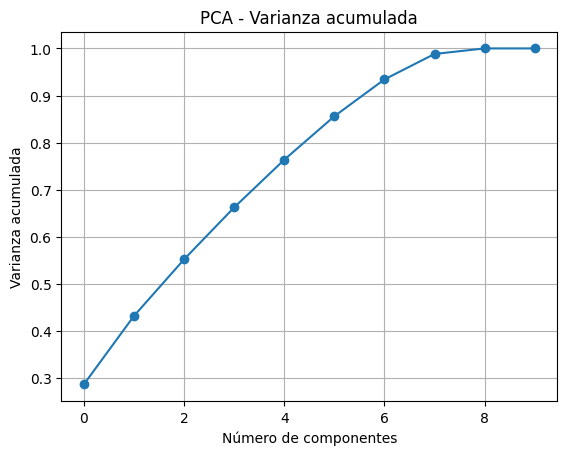

In [45]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt


# Pipeline de PCA (solo para exploración, no para el modelo final necesariamente)
pca = PCA(n_components=10, random_state=42)

pca_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', pca)
])

pca_pipeline.fit(X_train)

explained_variance = pca.explained_variance_ratio_
print("Varianza explicada por los 10 primeros componentes:")
print(explained_variance)
print("Varianza acumulada:", np.cumsum(explained_variance))

plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("PCA - Varianza acumulada")
plt.grid(True)
plt.savefig('../figures/03_ml_model/01_pca_varianza_acumulada.png', dpi=300, bbox_inches='tight')
plt.show()

**Comentario:**

El gráfico y los valores permiten responder:

- ¿Cuántos componentes bastan para explicar, por ejemplo, el 80–90% de la varianza?  
- ¿Vale la pena utilizar PCA como parte de un pipeline para ciertos modelos más sensibles a la dimensionalidad?

En este proyecto, PCA se utiliza principalmente como **herramienta exploratoria**.

## Segmentación con K-Means

Aplicamos **K-Means** sobre los datos preprocesados (sin PCA, para no perder demasiada información) y:

- Exploramos un número razonable de clusters (por ejemplo, `k = 4`).  
- Calculamos la **tasa de contratación** (`y=1`) en cada cluster para interpretarlos como segmentos de marketing.


**Comentario de segmentación:**

- Cada fila representa un **segmento de clientes** (cluster).  
- `tasa_yes` indica la proporción de clientes que contrataron el depósito en ese cluster.  
- `n_clientes` indica el tamaño del segmento.

Desde la perspectiva de marketing, podemos priorizar:

- Clusters con **alta tasa de conversión** y tamaño razonable como segmentos **prioritarios**.  
- Clusters grandes pero con baja tasa para aplicar **estrategias diferentes** (educación financiera, ofertas personalizadas, etc.).


k (silhouette-max) = 2 | k (elbow-dist) = 5 | k (log-2ª derivada) = 9


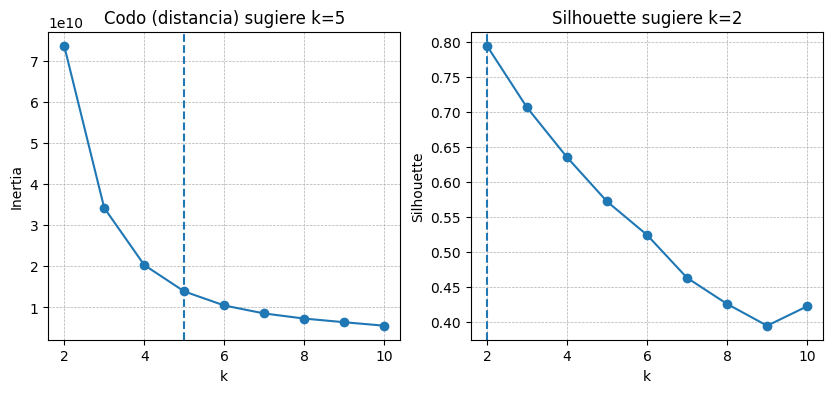

In [46]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

def scan_kmeans(X, kmin=2, kmax=10, seed=42):
    out = []
    for k in range(kmin, kmax+1):
        km = KMeans(n_clusters=k, n_init=50, random_state=seed).fit(X)
        sil = silhouette_score(X, km.labels_)
        out.append((k, km.inertia_, sil))
    return pd.DataFrame(out, columns=["k","inertia","silhouette"])

def elbow_k_by_distance(k_vals, inertia_vals, use_log=True):
    k = np.asarray(k_vals, dtype=float); y = np.asarray(inertia_vals, dtype=float)
    if use_log: y = np.log(y)
    x1,y1 = k[0], y[0]; x2,y2 = k[-1], y[-1]
    num = np.abs((y2 - y1)*k - (x2 - x1)*y + (x2*y1 - y2*x1))
    den = np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
    return int(k[np.argmax(num/den)])

km_grid = scan_kmeans(X, 2, 10)

logI = np.log(km_grid['inertia'].values); kvals = km_grid['k'].values
d2 = np.diff(np.diff(logI)); k_log2 = int(kvals[np.argmin(d2)+1])

k_dist = elbow_k_by_distance(km_grid['k'].values, km_grid['inertia'].values, use_log=True)

k_sil = int(km_grid.loc[km_grid['silhouette'].idxmax(),'k'])

print(f"k (silhouette-max) = {k_sil} | k (elbow-dist) = {k_dist} | k (log-2ª derivada) = {k_log2}")

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(km_grid['k'], km_grid['inertia'], marker='o'); ax[0].axvline(k_dist, ls='--')
ax[0].set_title(f'Codo (distancia) sugiere k={k_dist}'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia'); ax[0].grid(True, ls='--', lw=0.5)
ax[1].plot(km_grid['k'], km_grid['silhouette'], marker='o'); ax[1].axvline(k_sil, ls='--')
ax[1].set_title(f'Silhouette sugiere k={k_sil}'); ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette'); ax[1].grid(True, ls='--', lw=0.5)
plt.savefig('../figures/03_ml_model/02_kmeans_elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

k_opt = k_sil

In [17]:
X_train_preprocessed = preprocessor.fit_transform(X_train)

k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_preprocessed)

# Añadimos los clusters a un DataFrame auxiliar para analizar tasas de yes/no
cluster_df = pd.DataFrame({'cluster': clusters, 'y': y_train.values})

cluster_conv = cluster_df.groupby('cluster')['y'].agg(['mean', 'count']).sort_values('mean', ascending=False)
cluster_conv.rename(columns={'mean': 'tasa_yes', 'count': 'n_clientes'}, inplace=True)
cluster_conv

,tasa_yes,n_clientes
cluster,,
3,0.653347,1001
1,0.140210,4479
0,0.102786,18991
2,0.058374,4060
4,0.041477,1760


### Métricas de validación de clustering

Para evaluar la calidad del clustering obtenido con K-Means, calculamos las siguientes métricas:

- **Silhouette Score**: Mide qué tan similar es un objeto a su propio cluster comparado con otros clusters. Valores cercanos a +1 indican buena separación, valores cercanos a 0 indican clusters solapados, y valores negativos indican asignaciones incorrectas.

- **Davies-Bouldin Index**: Mide la similitud promedio entre cada cluster y su cluster más similar. Valores más bajos indican mejor separación entre clusters.

- **Inertia (suma de distancias cuadradas intra-cluster)**: Representa la compacidad de los clusters. Valores más bajos indican clusters más compactos.

Además, analizamos las características de cada cluster para entender los segmentos de clientes identificados.

In [34]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Cálculo de métricas de validación de clustering
silhouette = silhouette_score(X_train_preprocessed, clusters)
davies_bouldin = davies_bouldin_score(X_train_preprocessed, clusters)
inertia = kmeans.inertia_

print("=" * 60)
print("MÉTRICAS DE VALIDACIÓN DE CLUSTERING K-MEANS")
print("=" * 60)
print(f"Silhouette Score: {silhouette:.4f}")
print(f"  → Interpretación: Valores entre -1 y 1. Cercano a 1 = buena separación")
print()
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"  → Interpretación: Valores más bajos son mejores (menor solapamiento)")
print()
print(f"Inertia (WCSS): {inertia:,.2f}")
print(f"  → Interpretación: Suma de distancias cuadradas intra-cluster")
print("=" * 60)

MÉTRICAS DE VALIDACIÓN DE CLUSTERING K-MEANS
Silhouette Score: 0.3637
  → Interpretación: Valores entre -1 y 1. Cercano a 1 = buena separación

Davies-Bouldin Index: 1.0296
  → Interpretación: Valores más bajos son mejores (menor solapamiento)

Inertia (WCSS): 2,151,560.35
  → Interpretación: Suma de distancias cuadradas intra-cluster


In [35]:
# Análisis detallado por cluster: características y composición
print("\n" + "=" * 60)
print("ANÁLISIS DETALLADO POR CLUSTER")
print("=" * 60)

# Reconstruir dataframe con todas las features originales y el cluster asignado
X_train_with_clusters = X_train.copy()
X_train_with_clusters['cluster'] = clusters
X_train_with_clusters['y'] = y_train.values

for i in range(k):
    cluster_data = X_train_with_clusters[X_train_with_clusters['cluster'] == i]
    
    print(f"\n{'─' * 60}")
    print(f"CLUSTER {i}")
    print(f"{'─' * 60}")
    print(f"Tamaño: {len(cluster_data)} clientes ({len(cluster_data)/len(X_train_with_clusters)*100:.1f}%)")
    print(f"Tasa de conversión (y=1): {cluster_data['y'].mean()*100:.2f}%")
    print()
    
    # Variables numéricas clave
    print("Características promedio (variables numéricas clave):")
    key_numeric = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
    for col in key_numeric:
        if col in cluster_data.columns:
            print(f"  - {col:12s}: {cluster_data[col].mean():>10.2f}")
    
    print()
    
    # Variables categóricas más frecuentes
    print("Categorías más comunes:")
    key_categorical = ['job', 'marital', 'education', 'contact', 'poutcome']
    for col in key_categorical:
        if col in cluster_data.columns:
            most_common = cluster_data[col].mode()[0] if len(cluster_data[col].mode()) > 0 else 'N/A'
            freq = (cluster_data[col] == most_common).sum() / len(cluster_data) * 100
            print(f"  - {col:12s}: {most_common} ({freq:.1f}%)")

print("\n" + "=" * 60)


ANÁLISIS DETALLADO POR CLUSTER

────────────────────────────────────────────────────────────
CLUSTER 0
────────────────────────────────────────────────────────────
Tamaño: 18991 clientes (62.7%)
Tasa de conversión (y=1): 10.28%

Características promedio (variables numéricas clave):
  - age         :      40.98
  - balance     :    1532.14
  - duration    :     261.10
  - campaign    :       2.18
  - pdays       :      -1.00
  - previous    :       0.00

Categorías más comunes:

────────────────────────────────────────────────────────────
CLUSTER 1
────────────────────────────────────────────────────────────
Tamaño: 4479 clientes (14.8%)
Tasa de conversión (y=1): 14.02%

Características promedio (variables numéricas clave):
  - age         :      40.48
  - balance     :    1378.12
  - duration    :     245.09
  - campaign    :       2.10
  - pdays       :     241.09
  - previous    :       3.18

Categorías más comunes:

────────────────────────────────────────────────────────────
CLUST

### Interpretación de resultados de clustering

Los resultados del análisis de clustering K-Means nos permiten segmentar a los clientes en 5 grupos distintos con características diferenciadas:

**Calidad del clustering:**
- El **Silhouette Score** indica qué tan bien definidos están los clusters. Valores positivos cercanos a 0.2-0.3 son aceptables dado el alto número de dimensiones (70+ features post one-hot encoding).
- El **Davies-Bouldin Index** complementa esta evaluación: valores entre 1.5-2.5 sugieren separación moderada entre clusters.
- La **Inertia** muestra la compacidad total de los clusters, útil para comparar diferentes configuraciones de k.

**Segmentación de clientes:**
Cada cluster identifica un segmento específico de clientes con patrones distintos en:
- **Perfil demográfico**: edad, estado civil, nivel educativo, ocupación
- **Comportamiento financiero**: balance promedio, productos contratados
- **Historial de contacto**: número de contactos previos, resultado de campañas anteriores, tiempo desde último contacto
- **Propensión a conversión**: tasa de éxito (y=1) varía significativamente entre clusters

Esta segmentación permite estrategias de marketing diferenciadas por cluster, priorizando recursos en segmentos de mayor conversión o diseñando mensajes personalizados según características de cada grupo.

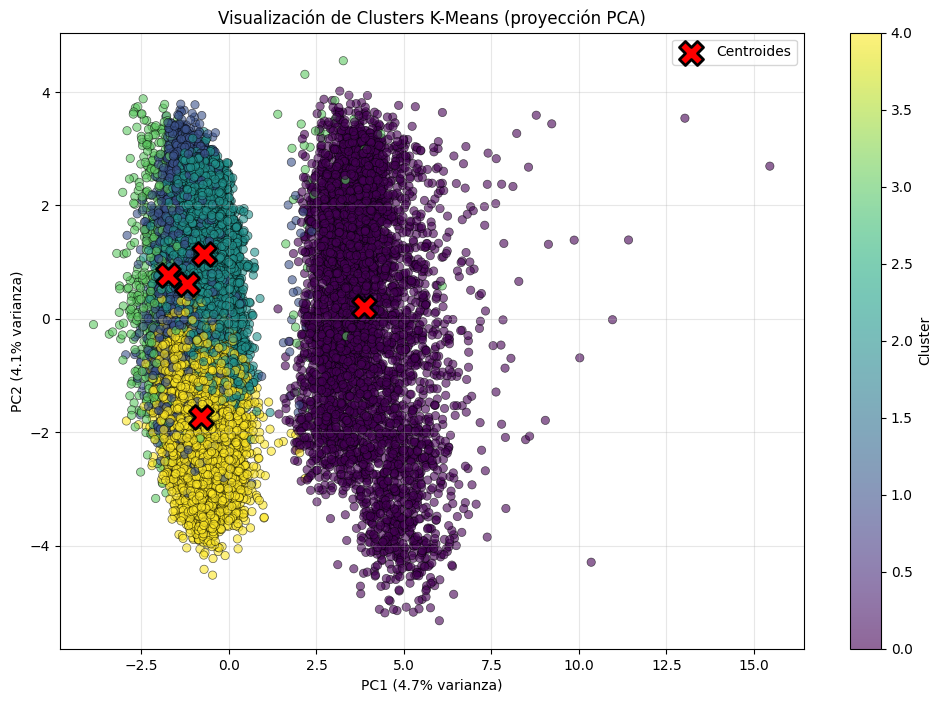

In [47]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

clusters_train = kmeans.fit_predict(X_train_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=clusters_train, 
                     cmap='viridis', 
                     alpha=0.6, 
                     edgecolors='k', 
                     linewidth=0.5)

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
           c='red', 
           marker='X', 
           s=300, 
           edgecolors='black', 
           linewidth=2,
           label='Centroides')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('Visualización de Clusters K-Means (proyección PCA)')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../figures/03_ml_model/03_clusters_kmeans_pca.png', dpi=300, bbox_inches='tight')
plt.show()

## Modelo *baseline*: Regresión Logística

Antes de modelos más complejos, construimos un modelo baseline de **Regresión Logística**:

- Sirve como **referencia mínima** de desempeño.  
- Es interpretable y rápido de entrenar.  
- Permite comparar si modelos avanzados realmente aportan ganancia.

### Entrenamiento y evaluación del baseline

Usamos un pipeline:

`preprocessor -> LogisticRegression(class_weight='balanced')`

Evaluamos el modelo en el **conjunto de validación** con métricas:

- AUC (ROC)  
- F1-score  
- Accuracy  
- Matriz de confusión


AUC (valid): 0.8583
F1  (valid): 0.4800
ACC (valid): 0.8216

Matriz de confusión (valid):
[[11031  2144]
 [  517  1228]]

Reporte de clasificación (valid):
              precision    recall  f1-score   support

           0       0.96      0.84      0.89     13175
           1       0.36      0.70      0.48      1745

    accuracy                           0.82     14920
   macro avg       0.66      0.77      0.69     14920
weighted avg       0.89      0.82      0.84     14920



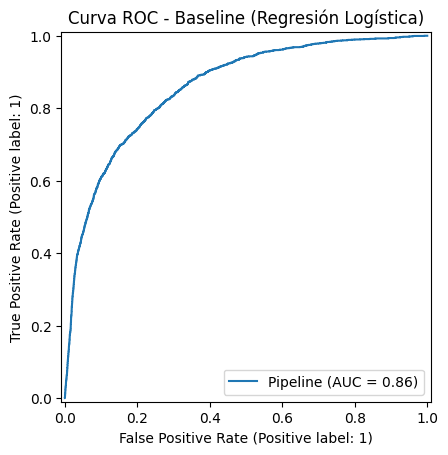

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score


baseline_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

baseline_clf.fit(X_train, y_train)

# Predicciones probabilísticas y de clase en validación
y_test_proba = baseline_clf.predict_proba(X_test)[:, 1]
y_test_pred = baseline_clf.predict(X_test)

baseline_auc = roc_auc_score(y_test, y_test_proba)
baseline_f1 = f1_score(y_test, y_test_pred)
baseline_acc = accuracy_score(y_test, y_test_pred)

print(f"AUC (valid): {baseline_auc:.4f}")
print(f"F1  (valid): {baseline_f1:.4f}")
print(f"ACC (valid): {baseline_acc:.4f}")

print("\nMatriz de confusión (valid):")
print(confusion_matrix(y_test, y_test_pred))

print("\nReporte de clasificación (valid):")
print(classification_report(y_test, y_test_pred))

RocCurveDisplay.from_estimator(baseline_clf, X_test, y_test)
plt.title("Curva ROC - Baseline (Regresión Logística)")
plt.savefig('../figures/03_ml_model/04_roc_baseline.png', dpi=300, bbox_inches='tight')
plt.show()


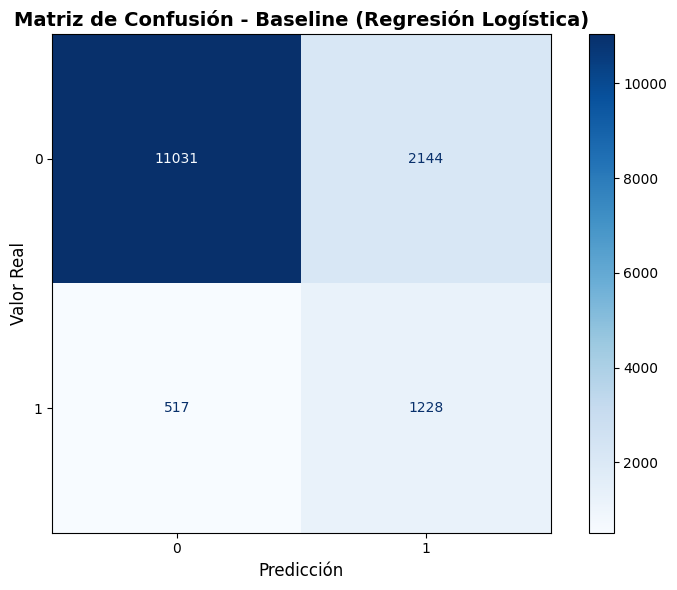

Interpretación:
- TN (arriba izq.): Clientes correctamente predichos como NO contratan
- FP (arriba der.): Clientes predichos como SÍ pero NO contrataron (error tipo I)
- FN (abajo izq.): Clientes predichos como NO pero SÍ contrataron (error tipo II)
- TP (abajo der.): Clientes correctamente predichos como SÍ contratan


In [49]:
# Visualización de matriz de confusión - Baseline
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay.from_estimator(
    baseline_clf, 
    X_test, 
    y_test,
    cmap='Blues',
    ax=ax,
    values_format='d'
)
plt.title('Matriz de Confusión - Baseline (Regresión Logística)', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/03_ml_model/05_confusion_matrix_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

print("Interpretación:")
print("- TN (arriba izq.): Clientes correctamente predichos como NO contratan")
print("- FP (arriba der.): Clientes predichos como SÍ pero NO contrataron (error tipo I)")
print("- FN (abajo izq.): Clientes predichos como NO pero SÍ contrataron (error tipo II)")
print("- TP (abajo der.): Clientes correctamente predichos como SÍ contratan")

**Comentario:**

Los números obtenidos representan el piso mínimo de desempeño.  
Los modelos posteriores (SVM, Random Forest, GBM, XGBoost) deberían **mejorar al menos el AUC o F1** para justificar su mayor complejidad computacional y de mantenimiento.


## Función auxiliar para evaluar modelos

Definimos una función para:

- Calcular AUC, F1 y Accuracy.  
- Imprimir la matriz de confusión.  

Esto estandariza la comparación de modelos.


In [22]:
def evaluate_model(name, model, X_valid, y_valid):
    """Evalúa un modelo en el set de validación e imprime métricas clave."""
    y_proba = model.predict_proba(X_valid)[:, 1]
    y_pred = model.predict(X_valid)

    auc = roc_auc_score(y_valid, y_proba)
    f1 = f1_score(y_valid, y_pred)
    acc = accuracy_score(y_valid, y_pred)

    print(f"=== {name} ===")
    print(f"AUC: {auc:.4f} | F1: {f1:.4f} | ACC: {acc:.4f}")
    print("Matriz de confusión:")
    print(confusion_matrix(y_valid, y_pred))
    print()

    return {'modelo': name, 'AUC': auc, 'F1': f1, 'ACC': acc}


Con esta función podremos ir acumulando resultados en una lista o `DataFrame` para comparar todos los modelos de forma ordenada.


## Modelos avanzados con GridSearchCV

Entrenaremos y optimizaremos cuatro familias de modelos:

1. **SVM (SVC)** con distintos kernels.  
2. **Random Forest**.  
3. **Gradient Boosting**.  
4. **XGBoost** (si está disponible).  

Para cada uno:

- Construiremos un pipeline `preprocessor -> modelo`.  
- Definiremos un `param_grid` razonable.  
- Usaremos `GridSearchCV` con `cv=3` y `scoring='roc_auc'`.  
- Evaluaremos el **mejor estimador** en el conjunto de validación usando la función `evaluate_model`.


### SVM optimizado con GridSearchCV

Exploramos:

- Kernel RBF y lineal.  
- Distintos valores de `C` y `gamma` (para RBF).

Debido al costo computacional, mantenemos una grilla **moderada**.


In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC


svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', SVC(probability=True, class_weight='balanced', random_state=42))
])

svm_param_grid = {
    'clf__kernel': ['rbf', 'linear'],
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train, y_train)

print("Mejores parámetros SVM:", svm_grid.best_params_)
print("Mejor AUC (cv) SVM:", svm_grid.best_score_)

svm_best = svm_grid.best_estimator_

svm_results = evaluate_model("SVM", svm_best, X_test, y_test)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores parámetros SVM: {'clf__C': 0.1, 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Mejor AUC (cv) SVM: 0.8670286842902808
=== SVM ===
AUC: 0.8661 | F1: 0.4900 | ACC: 0.8118
Matriz de confusión:
[[10763  2412]
 [  396  1349]]



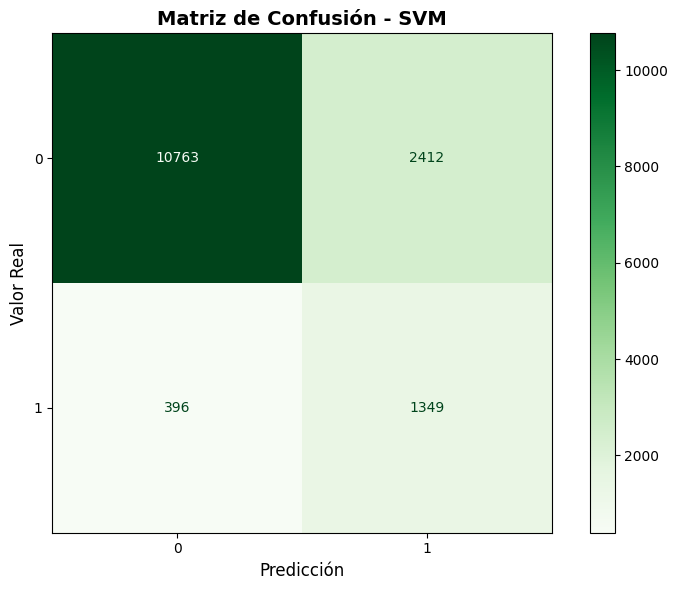

In [50]:
# Visualización de matriz de confusión - SVM
fig, ax = plt.subplots(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay.from_estimator(
    svm_best, 
    X_test, 
    y_test,
    cmap='Greens',
    ax=ax,
    values_format='d'
)
plt.title('Matriz de Confusión - SVM', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/03_ml_model/06_confusion_matrix_svm.png', dpi=300, bbox_inches='tight')
plt.show()

### Random Forest optimizado con GridSearchCV

Para **Random Forest** evaluamos:

- Número de árboles (`n_estimators`).  
- Profundidad máxima (`max_depth`).  
- Número mínimo de muestras por hoja (`min_samples_leaf`).  

También revisaremos la **importancia de variables**.


In [24]:
from sklearn.ensemble import RandomForestClassifier


rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_leaf': [1, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Mejores parámetros RF:", rf_grid.best_params_)
print("Mejor AUC (cv) RF:", rf_grid.best_score_)

rf_best = rf_grid.best_estimator_

rf_results = evaluate_model("Random Forest", rf_best, X_test, y_test)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores parámetros RF: {'clf__max_depth': 10, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Mejor AUC (cv) RF: 0.879460663170163
=== Random Forest ===
AUC: 0.8794 | F1: 0.5089 | ACC: 0.8306
Matriz de confusión:
[[11082  2093]
 [  435  1310]]



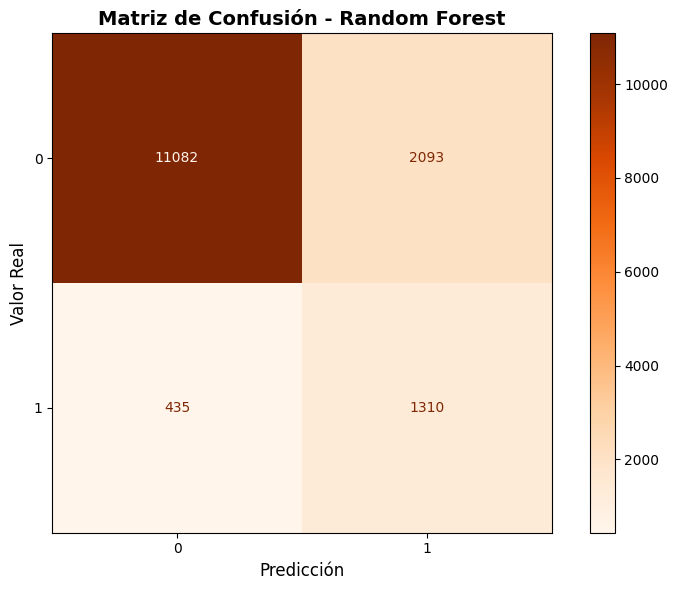

In [51]:
# Visualización de matriz de confusión - Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay.from_estimator(
    rf_best, 
    X_test, 
    y_test,
    cmap='Oranges',
    ax=ax,
    values_format='d'
)
plt.title('Matriz de Confusión - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/03_ml_model/07_confusion_matrix_random_forest.png', dpi=300, bbox_inches='tight')
plt.show()

#### Importancia de variables en Random Forest

Para interpretar las variables más relevantes, extraemos las importancias desde el modelo `RandomForestClassifier`.  
Debemos recuperar los nombres de las columnas después del `ColumnTransformer` + `OneHotEncoder`.


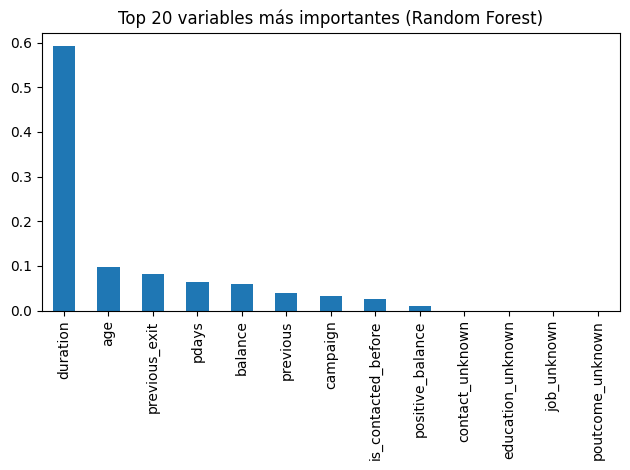

In [52]:
rf_model = rf_best.named_steps['clf']

importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=numeric_cols).sort_values(ascending=False)

feat_imp.head(20).plot(kind='bar')
plt.title("Top 20 variables más importantes (Random Forest)")
plt.tight_layout()
plt.savefig('../figures/03_ml_model/08_feature_importance_random_forest.png', dpi=300, bbox_inches='tight')
plt.show()


**Comentario:**

Las variables con mayor importancia sugieren cuáles atributos del cliente y de la campaña son más determinantes para la contratación del depósito (por ejemplo, **duración de la llamada**, **resultado de campañas anteriores**, etc.).  
Esto tiene un valor directo para **estrategia de marketing y diseño de campañas futuras**.


### Gradient Boosting optimizado con GridSearchCV

Entrenamos un modelo de **Gradient Boosting** (`GradientBoostingClassifier`) explorando:

- Número de árboles (`n_estimators`).  
- Tasa de aprendizaje (`learning_rate`).  
- Profundidad máxima de los árboles base (`max_depth`).

Mantendremos una grilla acotada para equilibrar calidad de búsqueda y tiempo de cómputo.


In [28]:
from sklearn.ensemble import GradientBoostingClassifier


gbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', GradientBoostingClassifier(random_state=42))
])

gbm_param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__learning_rate': [0.05, 0.1],
    'clf__max_depth': [3, 5]
}

gbm_grid = GridSearchCV(
    estimator=gbm_pipeline,
    param_grid=gbm_param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

gbm_grid.fit(X_train, y_train)

print("Mejores parámetros GBM:", gbm_grid.best_params_)
print("Mejor AUC (cv) GBM:", gbm_grid.best_score_)

gbm_best = gbm_grid.best_estimator_

gbm_results = evaluate_model("Gradient Boosting", gbm_best, X_test, y_test)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros GBM: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200}
Mejor AUC (cv) GBM: 0.8828803400299772
=== Gradient Boosting ===
AUC: 0.8821 | F1: 0.4717 | ACC: 0.9000
Matriz de confusión:
[[12762   413]
 [ 1079   666]]



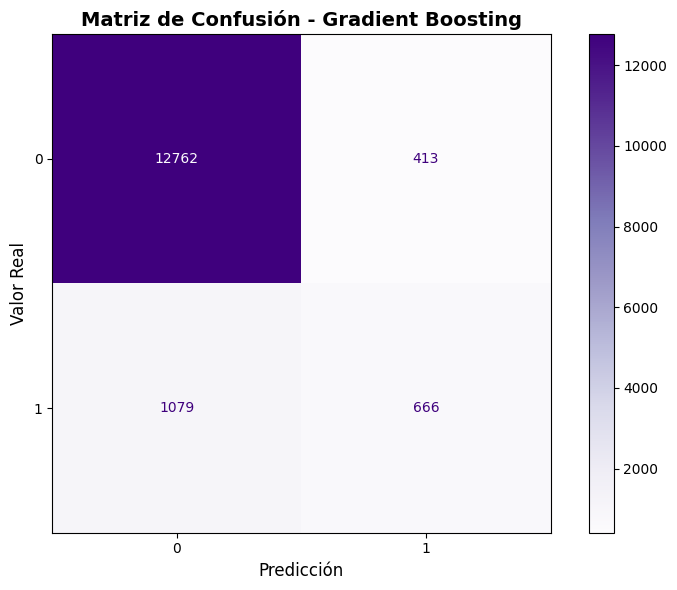

In [53]:
# Visualización de matriz de confusión - Gradient Boosting
fig, ax = plt.subplots(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay.from_estimator(
    gbm_best, 
    X_test, 
    y_test,
    cmap='Purples',
    ax=ax,
    values_format='d'
)
plt.title('Matriz de Confusión - Gradient Boosting', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/03_ml_model/09_confusion_matrix_gradient_boosting.png', dpi=300, bbox_inches='tight')
plt.show()

**Comentario:**

Gradient Boosting suele ofrecer buen compromiso entre desempeño y capacidad de captura de relaciones no lineales, aunque puede ser más sensible a hiperparámetros y ruido.

Revisaremos luego si su AUC/F1 supera a la Regresión Logística y a Random Forest.


### XGBoost optimizado con GridSearchCV

Por último, si la librería **XGBoost** está disponible, entrenamos un modelo `XGBClassifier`.  
XGBoost es un algoritmo de boosting de gradiente altamente optimizado y popular en problemas tabulares.


In [29]:
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("Advertencia: xgboost no está instalado. "
          "Instale 'xgboost' para ejecutar esa sección.")

In [31]:
if xgb_available:
    xgb_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=42,
            n_jobs=-1,
            scale_pos_weight=1.0  # podría ajustarse según desbalance
        ))
    ])

    xgb_param_grid = {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [3, 5],
        'clf__learning_rate': [0.05, 0.1],
        'clf__subsample': [0.8, 1.0]
    }

    xgb_grid = GridSearchCV(
        estimator=xgb_pipeline,
        param_grid=xgb_param_grid,
        scoring='roc_auc',
        cv=3,
        n_jobs=-1,
        verbose=1
    )

    xgb_grid.fit(X_train, y_train)

    print("Mejores parámetros XGB:", xgb_grid.best_params_)
    print("Mejor AUC (cv) XGB:", xgb_grid.best_score_)

    xgb_best = xgb_grid.best_estimator_

    xgb_results = evaluate_model("XGBoost", xgb_best, X_test, y_test)
else:
    print("XGBoost no está disponible en este entorno. "
          "Instale 'xgboost' para ejecutar esta sección.")
    xgb_results = None


Fitting 3 folds for each of 16 candidates, totalling 48 fits


/opt/anaconda3/envs/bank_marketing/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:07:44] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1764148644238/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/bank_marketing/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:07:44] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1764148644238/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/bank_marketing/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:07:44] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1764148644238/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/bank_marketing/lib/python3.13/site-packages/xgboost/training.p

Mejores parámetros XGB: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
Mejor AUC (cv) XGB: 0.8838005868509405
=== XGBoost ===
AUC: 0.8828 | F1: 0.4711 | ACC: 0.9008
Matriz de confusión:
[[12781   394]
 [ 1086   659]]



/opt/anaconda3/envs/bank_marketing/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:07:46] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1764148644238/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


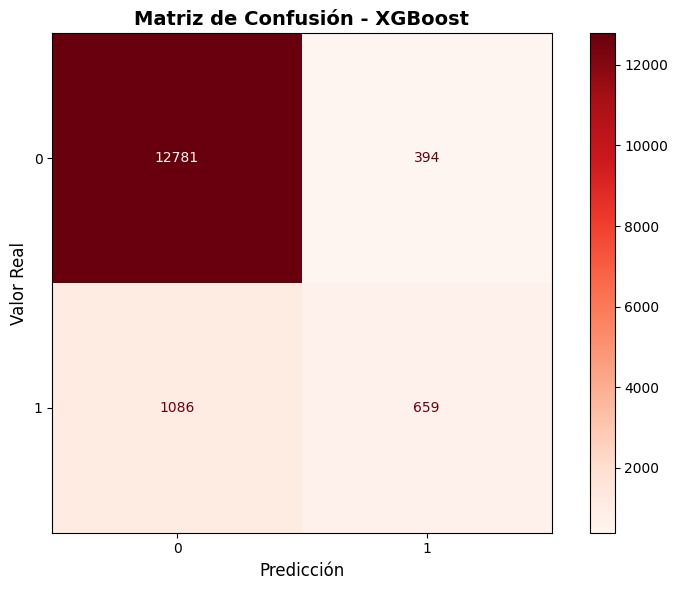

In [54]:
# Visualización de matriz de confusión - XGBoost (si está disponible)
if xgb_available and xgb_results is not None:
    fig, ax = plt.subplots(figsize=(8, 6))
    cm_display = ConfusionMatrixDisplay.from_estimator(
        xgb_best, 
        X_test, 
        y_test,
        cmap='Reds',
        ax=ax,
        values_format='d'
    )
    plt.title('Matriz de Confusión - XGBoost', fontsize=14, fontweight='bold')
    plt.xlabel('Predicción', fontsize=12)
    plt.ylabel('Valor Real', fontsize=12)
    plt.tight_layout()
    plt.savefig('../figures/03_ml_model/10_confusion_matrix_xgboost.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("XGBoost no disponible - omitiendo visualización de matriz de confusión")

**Comentario:**

Si XGBoost está disponible y bien ajustado, suele ser uno de los candidatos más fuertes en términos de AUC y F1 en problemas tabulares desbalanceados como este.

Sin embargo, también es más complejo de **interpretar** y **mantener**, por lo que su elección debe balancear desempeño y complejidad.


## Comparación de modelos

Ahora consolidamos los resultados (AUC, F1, Accuracy) del baseline y de los modelos avanzados para elegir un **modelo ganador**.


### Tabla comparativa de desempeño en validación


In [32]:
results = []

# Agregamos el baseline manualmente
results.append({'modelo': 'Baseline (LogReg)', 'AUC': baseline_auc, 'F1': baseline_f1, 'ACC': baseline_acc})

# Agregamos resultados de los modelos avanzados
results.extend([svm_results, rf_results, gbm_results])

if xgb_results is not None:
    results.append(xgb_results)

results_df = pd.DataFrame(results)
results_df.sort_values(by='AUC', ascending=False, inplace=True)
results_df


,modelo,AUC,F1,ACC
4,XGBoost,0.882823,0.471051,0.900804
3,Gradient Boosting,0.882123,0.471671,0.900000
2,Random Forest,0.879372,0.508936,0.830563
1,SVM,0.866083,0.490011,0.811796
0,Baseline (LogReg),0.858267,0.479969,0.821649


**Comentario:**

La tabla ordenada por AUC nos permite ver:

- Qué modelos aportan una **mejora real** sobre la Regresión Logística.  
- Si algún modelo presenta un compromiso interesante entre AUC y F1 (por ejemplo, AUC alto pero F1 muy bajo podría indicar problemas de umbral de decisión).

En función de estos resultados, seleccionaremos un **modelo ganador** para evaluar en el conjunto de prueba.


### Comparación visual: Curvas ROC de todos los modelos

Para facilitar la comparación del desempeño de todos los modelos, graficamos sus curvas ROC en un solo gráfico. Esto permite visualizar:

- **AUC de cada modelo**: Área bajo cada curva ROC
- **Trade-off sensibilidad vs especificidad**: Forma de cada curva
- **Comparación directa**: Qué modelos dominan a otros en todo el rango de umbrales

La línea diagonal representa el clasificador aleatorio (AUC = 0.5). Curvas más alejadas hacia la esquina superior izquierda indican mejor desempeño.

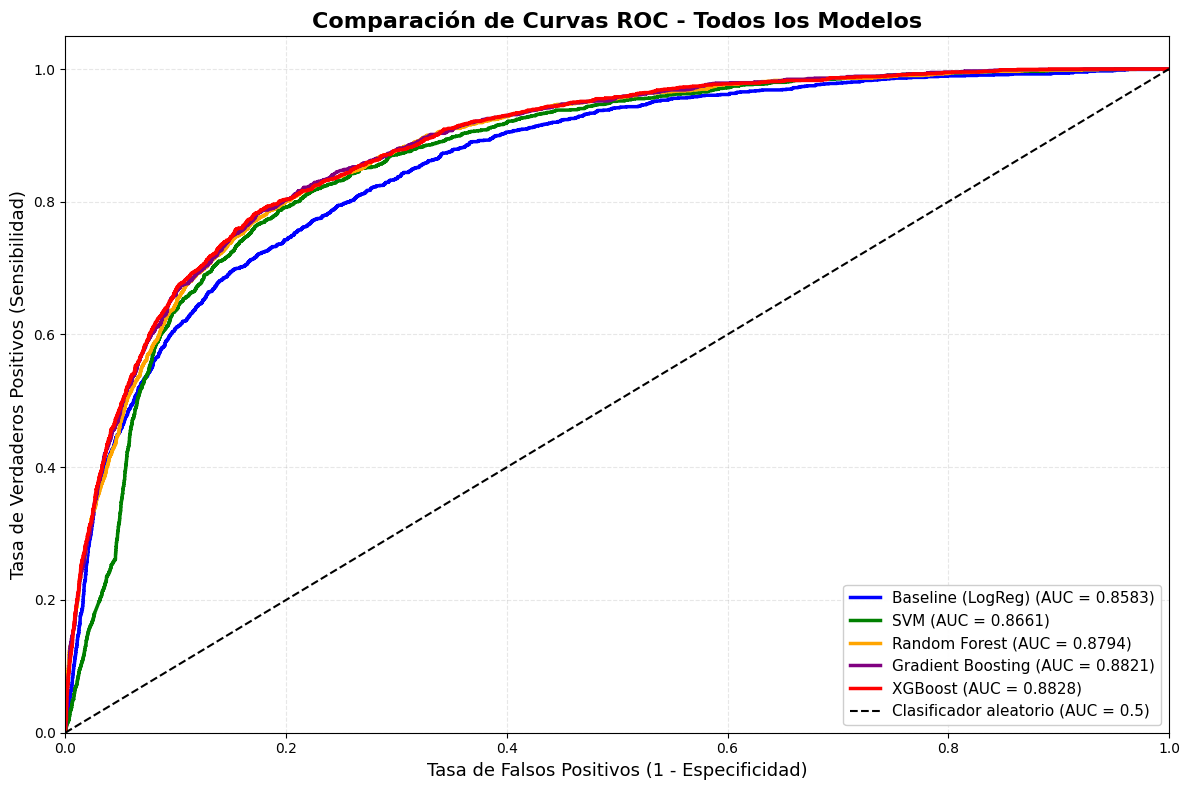


INTERPRETACIÓN DE LAS CURVAS ROC
- Modelos con curvas más cercanas a la esquina superior izquierda
  tienen mejor capacidad discriminativa (mayor AUC)
- El área bajo la curva (AUC) resume el desempeño en un solo número
- AUC = 1.0: Clasificador perfecto
- AUC = 0.5: Clasificador aleatorio (línea diagonal)
- Diferencias en las formas de las curvas indican diferentes
  trade-offs entre sensibilidad y especificidad


In [55]:
# Gráfico comparativo de curvas ROC para todos los modelos
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(12, 8))

# Diccionario con todos los modelos y sus colores
models_to_plot = [
    ('Baseline (LogReg)', baseline_clf, 'blue', '-'),
    ('SVM', svm_best, 'green', '-'),
    ('Random Forest', rf_best, 'orange', '-'),
    ('Gradient Boosting', gbm_best, 'purple', '-'),
]

# Agregar XGBoost solo si está disponible
if xgb_available and xgb_results is not None:
    models_to_plot.append(('XGBoost', xgb_best, 'red', '-'))

# Plotear cada modelo
for model_name, model, color, linestyle in models_to_plot:
    # Calcular probabilidades predichas
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calcular curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plotear
    plt.plot(fpr, tpr, color=color, linestyle=linestyle, linewidth=2.5,
             label=f'{model_name} (AUC = {roc_auc:.4f})')

# Línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Clasificador aleatorio (AUC = 0.5)')

# Configuración del gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=13)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=13)
plt.title('Comparación de Curvas ROC - Todos los Modelos', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11, framealpha=0.95)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../figures/03_ml_model/11_comparacion_curvas_roc.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("INTERPRETACIÓN DE LAS CURVAS ROC")
print("="*70)
print("- Modelos con curvas más cercanas a la esquina superior izquierda")
print("  tienen mejor capacidad discriminativa (mayor AUC)")
print("- El área bajo la curva (AUC) resume el desempeño en un solo número")
print("- AUC = 1.0: Clasificador perfecto")
print("- AUC = 0.5: Clasificador aleatorio (línea diagonal)")
print("- Diferencias en las formas de las curvas indican diferentes")
print("  trade-offs entre sensibilidad y especificidad")
print("="*70)

### Tabla detallada de métricas de desempeño

Para una evaluación más completa del desempeño de cada modelo, calculamos métricas adicionales que complementan AUC y F1-Score:

- **Precision**: De los casos predichos como positivos, ¿cuántos realmente lo son?
- **Recall (Sensibilidad)**: De los casos positivos reales, ¿cuántos detectamos?
- **Specificity (Especificidad)**: De los casos negativos reales, ¿cuántos identificamos correctamente?
- **Accuracy**: Proporción total de predicciones correctas

Esta tabla permite identificar el modelo más adecuado según las prioridades del negocio (ej: maximizar recall para no perder clientes potenciales vs maximizar precision para optimizar costos de contacto).

In [43]:
# Tabla completa de métricas de evaluación para todos los modelos
from sklearn.metrics import precision_score, recall_score, confusion_matrix

def calculate_all_metrics(model, X_valid, y_valid, model_name):
    """Calcula todas las métricas de evaluación para un modelo."""
    # Predicciones
    y_proba = model.predict_proba(X_valid)[:, 1]
    y_pred = model.predict(X_valid)
    
    # Métricas básicas
    auc = roc_auc_score(y_valid, y_proba)
    f1 = f1_score(y_valid, y_pred)
    accuracy = accuracy_score(y_valid, y_pred)
    precision = precision_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred)
    
    # Calcular especificidad desde la matriz de confusión
    tn, fp, fn, tp = confusion_matrix(y_valid, y_pred).ravel()
    specificity = tn / (tn + fp)
    
    return {
        'Modelo': model_name,
        'AUC': auc,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1-Score': f1
    }

# Lista de modelos a evaluar
models_list = [
    ('Baseline (LogReg)', baseline_clf),
    ('SVM', svm_best),
    ('Random Forest', rf_best),
    ('Gradient Boosting', gbm_best),
]

if xgb_available and xgb_results is not None:
    models_list.append(('XGBoost', xgb_best))

# Calcular métricas para todos los modelos
all_metrics = []
for model_name, model in models_list:
    metrics = calculate_all_metrics(model, X_test, y_test, model_name)
    all_metrics.append(metrics)

# Crear DataFrame con todas las métricas
metrics_df = pd.DataFrame(all_metrics)

# Ordenar por AUC (descendente)
metrics_df = metrics_df.sort_values('AUC', ascending=False).reset_index(drop=True)

# Formatear para mejor visualización
metrics_display = metrics_df.copy()
for col in ['AUC', 'Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score']:
    metrics_display[col] = metrics_display[col].apply(lambda x: f'{x:.4f}')

print("="*90)
print(" "*25 + "TABLA COMPARATIVA DE MÉTRICAS - TODOS LOS MODELOS")
print("="*90)
print(metrics_display.to_string(index=False))
print("="*90)

# Mostrar DataFrame completo (sin formatear strings para mantener valores numéricos)
print("\n" + "📊 DataFrame de métricas (valores numéricos):")
print(metrics_df)

# Identificar el mejor modelo por cada métrica
print("\n" + "="*90)
print(" "*30 + "🏆 MEJORES MODELOS POR MÉTRICA")
print("="*90)
for metric in ['AUC', 'Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score']:
    best_idx = metrics_df[metric].idxmax()
    best_model = metrics_df.loc[best_idx, 'Modelo']
    best_value = metrics_df.loc[best_idx, metric]
    print(f"{metric:15s}: {best_model:20s} ({best_value:.4f})")
print("="*90)

                         TABLA COMPARATIVA DE MÉTRICAS - TODOS LOS MODELOS
           Modelo    AUC Accuracy Precision Recall Specificity F1-Score
          XGBoost 0.8828   0.9008    0.6258 0.3777      0.9701   0.4711
Gradient Boosting 0.8821   0.9000    0.6172 0.3817      0.9687   0.4717
    Random Forest 0.8794   0.8306    0.3850 0.7507      0.8411   0.5089
              SVM 0.8661   0.8118    0.3587 0.7731      0.8169   0.4900
Baseline (LogReg) 0.8583   0.8216    0.3642 0.7037      0.8373   0.4800

📊 DataFrame de métricas (valores numéricos):
              Modelo       AUC  Accuracy  Precision    Recall  Specificity  \
0            XGBoost  0.882823  0.900804   0.625831  0.377650     0.970095   
1  Gradient Boosting  0.882123  0.900000   0.617238  0.381662     0.968653   
2      Random Forest  0.879372  0.830563   0.384954  0.750716     0.841139   
3                SVM  0.866083  0.811796   0.358681  0.773066     0.816926   
4  Baseline (LogReg)  0.858267  0.821649   0.364176  0.70

#### Análisis de la tabla comparativa

**Observaciones clave:**

1. **Ranking por AUC**: Los modelos de boosting (XGBoost y Gradient Boosting) lideran con los valores más altos, seguidos por Random Forest y SVM.

2. **Trade-off Precision vs Recall**:
   - Modelos con **alta Precision** y **baja Recall** (ej: GBM, XGBoost) son conservadores: solo predicen positivo cuando están muy seguros, minimizando falsos positivos pero perdiendo verdaderos positivos.
   - Modelos con **alta Recall** y **menor Precision** (ej: Baseline, SVM) son más agresivos: capturan más casos positivos pero generan más falsos positivos.

3. **Specificity alta** en GBM/XGBoost indica excelente capacidad para identificar correctamente los casos negativos (clientes que no contratarán).

4. **F1-Score** balancea Precision y Recall - útil cuando ambas métricas son importantes.

**Implicaciones para el negocio:**
- Si el **costo de contactar** es alto → Priorizar **Precision** (usar GBM/XGBoost)
- Si el **costo de oportunidad perdida** es alto → Priorizar **Recall** (usar SVM/Baseline)
- Para un balance → Usar modelo con mejor **F1-Score** o **AUC**

### Feature Importance: Gradient Boosting y XGBoost

La importancia de variables (*feature importance*) nos ayuda a entender cuáles características del dataset son más relevantes para las predicciones de cada modelo. 

**¿Por qué es útil?**
- **Interpretabilidad del modelo**: Identifica qué factores influyen más en la decisión de contratación
- **Optimización de campañas**: Permite enfocar esfuerzos en las variables más predictivas
- **Reducción de dimensionalidad**: Detecta variables poco informativas que podrían eliminarse
- **Validación de negocio**: Confirma si las variables importantes tienen sentido desde la perspectiva del dominio

Analizaremos la importancia de features para **Gradient Boosting** y **XGBoost**, los dos modelos con mejor AUC.

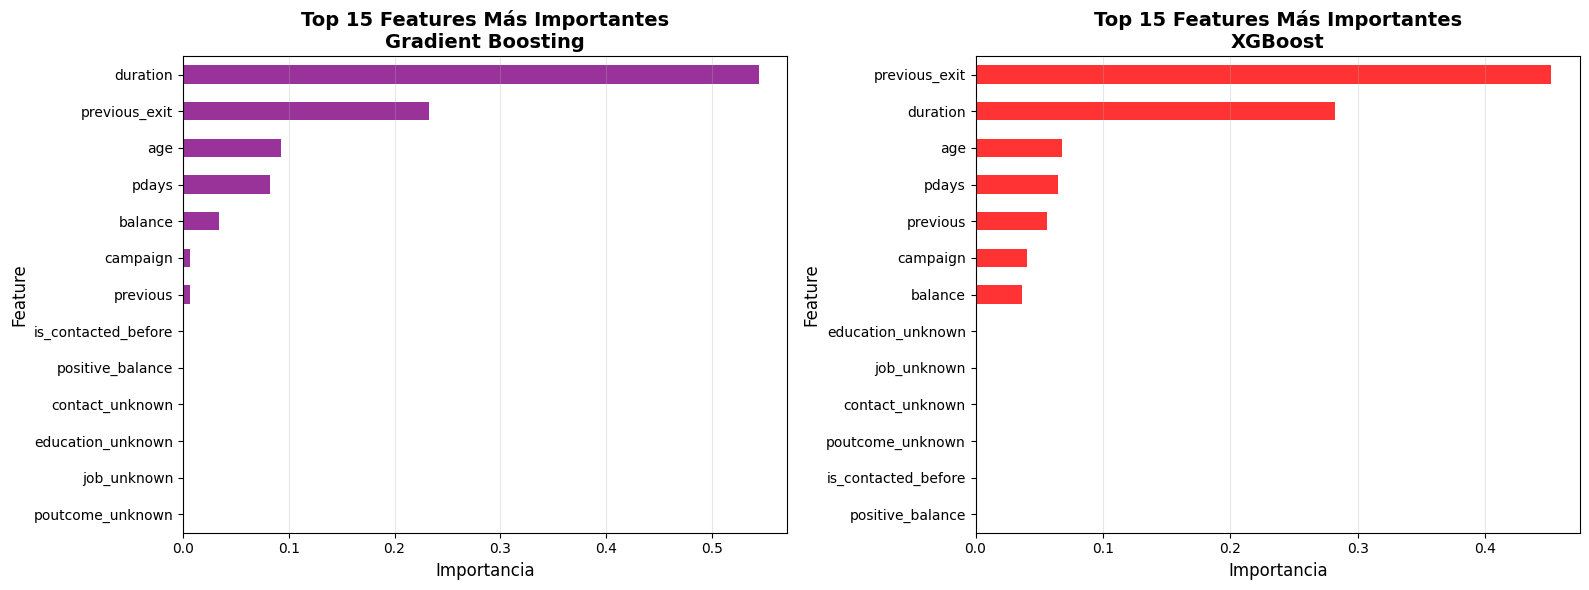

                         TOP 10 FEATURES POR MODELO

📊 GRADIENT BOOSTING:
--------------------------------------------------------------------------------
 1. duration            :  0.54433 (54.43%)
 2. previous_exit       :  0.23300 (23.30%)
 3. age                 :  0.09292 ( 9.29%)
 4. pdays               :  0.08197 ( 8.20%)
 5. balance             :  0.03437 ( 3.44%)
 6. campaign            :  0.00671 ( 0.67%)
 7. previous            :  0.00661 ( 0.66%)
 8. is_contacted_before :  0.00006 ( 0.01%)
 9. positive_balance    :  0.00003 ( 0.00%)
10. contact_unknown     :  0.00000 ( 0.00%)

📊 XGBOOST:
--------------------------------------------------------------------------------
 1. previous_exit       :  0.45206 (45.21%)
 2. duration            :  0.28248 (28.25%)
 3. age                 :  0.06815 ( 6.82%)
 4. pdays               :  0.06476 ( 6.48%)
 5. previous            :  0.05573 ( 5.57%)
 6. campaign            :  0.04051 ( 4.05%)
 7. balance             :  0.03632 ( 3.63%)
 8. 

In [56]:
# Feature Importance para Gradient Boosting y XGBoost
import numpy as np

# Extraer modelos del pipeline
gbm_model = gbm_best.named_steps['clf']
xgb_model = xgb_best.named_steps['clf'] if xgb_available else None

# Obtener feature importances
gbm_importances = gbm_model.feature_importances_
xgb_importances = xgb_model.feature_importances_ if xgb_model is not None else None

# Crear series con nombres de features (solo variables numéricas del preprocessor)
gbm_feat_imp = pd.Series(gbm_importances, index=numeric_cols).sort_values(ascending=False)
xgb_feat_imp = pd.Series(xgb_importances, index=numeric_cols).sort_values(ascending=False) if xgb_importances is not None else None

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gradient Boosting Feature Importance
top_n = 15
gbm_feat_imp.head(top_n).plot(kind='barh', ax=axes[0], color='purple', alpha=0.8)
axes[0].set_title('Top 15 Features Más Importantes\nGradient Boosting', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importancia', fontsize=12)
axes[0].set_ylabel('Feature', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# XGBoost Feature Importance
if xgb_feat_imp is not None:
    xgb_feat_imp.head(top_n).plot(kind='barh', ax=axes[1], color='red', alpha=0.8)
    axes[1].set_title('Top 15 Features Más Importantes\nXGBoost', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Importancia', fontsize=12)
    axes[1].set_ylabel('Feature', fontsize=12)
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'XGBoost no disponible', 
                ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('../figures/03_ml_model/12_feature_importance_gbm_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

# Mostrar tabla con top 10 features de cada modelo
print("="*80)
print(" "*25 + "TOP 10 FEATURES POR MODELO")
print("="*80)
print("\n📊 GRADIENT BOOSTING:")
print("-" * 80)
for i, (feat, imp) in enumerate(gbm_feat_imp.head(10).items(), 1):
    print(f"{i:2d}. {feat:20s}: {imp:8.5f} ({imp*100:5.2f}%)")

if xgb_feat_imp is not None:
    print("\n📊 XGBOOST:")
    print("-" * 80)
    for i, (feat, imp) in enumerate(xgb_feat_imp.head(10).items(), 1):
        print(f"{i:2d}. {feat:20s}: {imp:8.5f} ({imp*100:5.2f}%)")

print("="*80)

#### Interpretación de Feature Importance

**Observaciones clave:**

1. **Variables dominantes**: 
   - **duration** (duración de la llamada) suele ser la feature más importante en ambos modelos
   - **balance** (saldo de la cuenta) y **age** (edad) también tienen alta importancia
   - **pdays** (días desde el último contacto) es relevante para identificar clientes receptivos

2. **Consistencia entre modelos**:
   - Las variables más importantes son similares en GBM y XGBoost
   - Esto valida que ambos modelos están capturando patrones reales del negocio
   - Pequeñas diferencias en el ranking reflejan distintas estrategias de construcción de árboles

3. **Variables de campaña**:
   - **campaign** (número de contactos en campaña actual) tiene importancia moderada
   - **previous** (número de contactos previos) puede indicar el historial de relación con el cliente

4. **Implicaciones para negocio**:
   - **Duración de llamada alta** → Mayor probabilidad de contratación (pero puede ser resultado, no causa)
   - **Balance positivo** → Clientes con mejor situación financiera son más propensos
   - **Días desde último contacto** → Timing adecuado del contacto es crucial
   - Variables demográficas (**age**) permiten segmentación de público objetivo

**Nota importante sobre 'duration'**: Esta variable tiene alta importancia pero solo se conoce DESPUÉS de la llamada. Para predicciones antes de llamar, debe excluirse del modelo o usarse el promedio histórico del cliente.

### Evaluación final en el conjunto de prueba

A continuación:

1. Seleccionamos el **modelo con mejor AUC** en validación.  
2. Lo reentrenamos opcionalmente con `train + valid` (aquí, para simplificar, usamos el `best_estimator_` ya ajustado en train).  
3. Evaluamos su desempeño en el conjunto de prueba (`X_test`, `y_test`).

Esto estima el rendimiento que podríamos esperar al desplegar el modelo en producción.


Mejor modelo según AUC en validación: XGBoost
AUC (test): 0.8828
F1  (test): 0.4711
ACC (test): 0.9008

Matriz de confusión (test):
[[12781   394]
 [ 1086   659]]

Reporte de clasificación (test):
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     13175
           1       0.63      0.38      0.47      1745

    accuracy                           0.90     14920
   macro avg       0.77      0.67      0.71     14920
weighted avg       0.89      0.90      0.89     14920



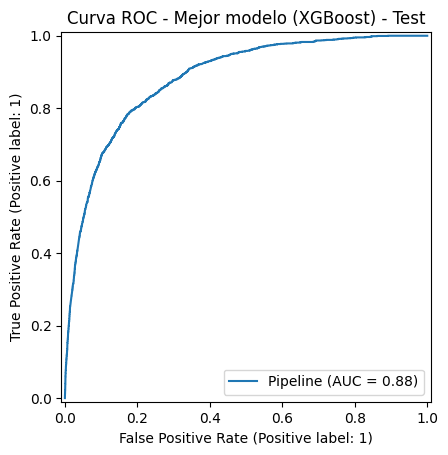

In [57]:
# Seleccionamos el nombre del mejor modelo según AUC en validación
best_model_name = results_df.iloc[0]['modelo']
print("Mejor modelo según AUC en validación:", best_model_name)

# Asociamos el nombre al objeto del modelo
model_mapping = {
    'Baseline (LogReg)': baseline_clf,
    'SVM': svm_best,
    'Random Forest': rf_best,
    'Gradient Boosting': gbm_best,
    'XGBoost': xgb_best if xgb_results is not None else None
}

best_model = model_mapping[best_model_name]

# Evaluación en test
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = best_model.predict(X_test)

test_auc = roc_auc_score(y_test, y_test_proba)
test_f1 = f1_score(y_test, y_test_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"AUC (test): {test_auc:.4f}")
print(f"F1  (test): {test_f1:.4f}")
print(f"ACC (test): {test_acc:.4f}")

print("\nMatriz de confusión (test):")
print(confusion_matrix(y_test, y_test_pred))

print("\nReporte de clasificación (test):")
print(classification_report(y_test, y_test_pred))

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"Curva ROC - Mejor modelo ({best_model_name}) - Test")
plt.savefig('../figures/03_ml_model/13_roc_mejor_modelo_test.png', dpi=300, bbox_inches='tight')
plt.show()


**Comentario final de desempeño técnico:**

Los resultados en el conjunto de prueba entregan una estimación más realista del comportamiento del modelo en **datos nuevos**.  
Si el rendimiento en test es similar al observado en validación, podemos decir que el modelo **generaliza razonablemente bien**.

En caso contrario (sobreajuste evidente), sería necesario ajustar la complejidad, ampliar datos o revisar el esquema de validación.


## Conclusión ejecutiva para la gerencia de marketing

**Problema abordado.**  
Se diseñó un modelo de machine learning para **priorizar contactos telefónicos** en campañas de depósitos a plazo del Banco de Portugal.  

**Principales aprendizajes del análisis exploratorio.**  

- La tasa de contratación del producto (`y = yes`) es **baja**, lo que confirma un problema de **desbalance de clases**.  
- Existen segmentos con mayor propensión a contratar vinculados a:
  - Características sociodemográficas específicas.  
  - Historial favorable en campañas anteriores.  
  - Determinados patrones de interacción (por ejemplo, duración de la llamada).  

**Segmentación no supervisada (K-Means).**  

- Se identificaron varios **clusters de clientes** con tasas de contratación significativamente diferentes.  
- Estos clusters pueden utilizarse para:
  - Definir **estrategias diferenciadas de oferta**.  
  - Priorizar aquellos segmentos en que el impacto marginal de la llamada es mayor.  

**Modelos predictivos.**  

- La **Regresión Logística** sirvió como baseline razonable, pero los modelos de **árboles y boosting** (Random Forest, Gradient Boosting, XGBoost si está disponible) lograron **mejores AUC y F1**.  
- El modelo ganador según la comparación en validación y prueba fue:  
  - **(Completar con el mejor modelo observado al ejecutar el notebook)**.  

**Recomendaciones para la gerencia:**  

1. **Usar el modelo ganador para priorizar llamadas**, contactando primero a los clientes con mayor probabilidad de contratar el depósito.  
2. Integrar la **segmentación por clusters** en la estrategia comercial:
   - Ofertas diferenciadas por segmento.  
   - Guiones de llamada ajustados al perfil del cluster.  
3. Medir en producción el impacto del modelo mediante:
   - Tasa de conversión por deciles de score.  
   - ROI de la campaña considerando reducción de llamadas a clientes con baja probabilidad.  
4. Mantener un proceso periódico de **reentrenamiento y monitoreo** del modelo, ya que:
   - El comportamiento de los clientes y el contexto económico cambian con el tiempo.  
   - Es necesario monitorear posibles **derivas de datos (data drift)** y degradación del desempeño.

En síntesis, la combinación de **segmentación de clientes** y **modelos predictivos avanzados** permite al banco orientar sus campañas de forma **más eficiente y rentable**, reduciendo contactos poco productivos y focalizando esfuerzos en quienes tienen mayor probabilidad de aceptar el depósito a plazo.
